In [ ]:
!wget https://github.com/matterport/Mask_RCNN/releases/download/v2.1/balloon_dataset.zip
!unzip balloon_dataset.zip

In [ ]:
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

In [1]:
import os,json
import cv2
import random
import numpy as np
from detectron2.structures import BoxMode
from detectron2.data import MetadataCatalog
from detectron2.data.catalog import DatasetCatalog
from detectron2.utils.visualizer import Visualizer
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.engine import DefaultTrainer
from detectron2.utils.visualizer import ColorMode

In [7]:
def get_balloon_dicts(img_dir):
    json_file = os.path.join(img_dir, "via_region_data.json")
    with open(json_file) as f:
        imgs_anns = json.load(f)

    dataset_dicts = []
    for idx, v in enumerate(imgs_anns.values()):
        result = {}
        img_path = os.path.join(img_dir, v['filename'])
        result["file_name"] = img_path
        result['height'], result['width'], _ = cv2.imread(img_path).shape
        result['image_id'] = idx
        annotations_data = v['regions']
        annotations = []
        for ann_key in annotations_data:
            segmentation = annotations_data[ann_key]['shape_attributes']
            xs = segmentation['all_points_x']
            ys = segmentation['all_points_y']
            combined_points = []
            for x, y in zip(xs, ys):
                combined_points.append(x+0.5)
                combined_points.append(y+0.5)
            segmentation_dict = {}
            segmentation_dict["segmentation"] = [combined_points]
            segmentation_dict["bbox_mode"] = BoxMode.XYXY_ABS
            x1,x2,y1,y2 = np.min(xs), np.max(xs), np.min(ys), np.max(ys)
            segmentation_dict["bbox"] = [x1,y1,x2,y2]
            segmentation_dict["category_id"] = 0
            annotations.append(segmentation_dict)
        result['annotations'] = annotations
        dataset_dicts.append(result)
    return dataset_dicts

In [3]:
for d in ["train", "val"]:
    DatasetCatalog.register("balloon_" + d, lambda d=d: get_balloon_dicts("balloon/" + d))
    MetadataCatalog.get("balloon_" + d).set(thing_classes=["balloon"])
balloon_metadata = MetadataCatalog.get("balloon_train")

balloon/train/7308740338_591f27b631_k.jpg


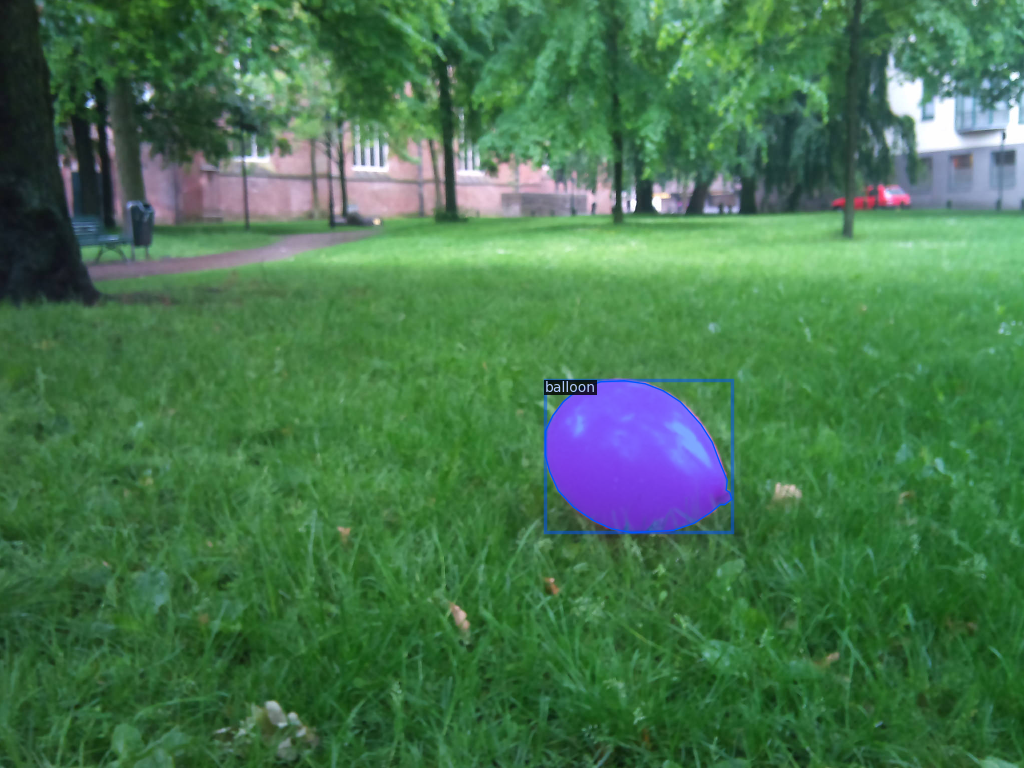

balloon/train/4955354786_337a598e4a_b.jpg


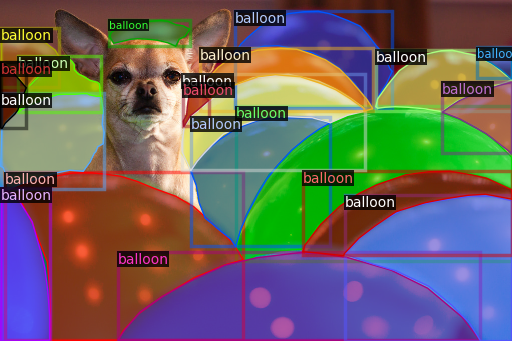

balloon/train/5253122239_38b1e7f61c_b.jpg


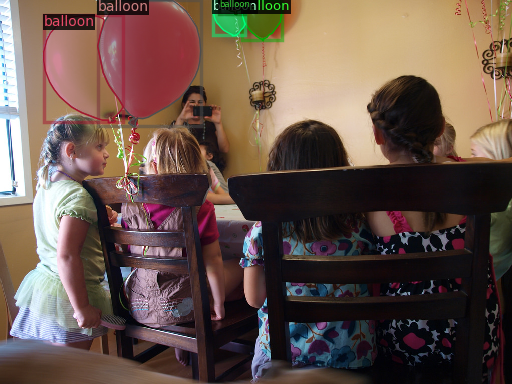

In [8]:
from IPython.display import display

import PIL.Image

dataset_dicts = get_balloon_dicts("balloon/train")
samples = random.sample(dataset_dicts, min(3, len(dataset_dicts)))

for d in samples:
    print(d["file_name"])
    img_bgr = cv2.imread(d["file_name"])
    if img_bgr is None:
        print("Could not read:", d["file_name"])
        continue

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    visualizer = Visualizer(img_rgb, metadata=balloon_metadata, scale=0.5)
    out = visualizer.draw_dataset_dict(d)

    img_pil = PIL.Image.fromarray(out.get_image())
    display(img_pil)


In [27]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("balloon_train",)
cfg.DATASETS.TEST = ()

cfg.DATALOADER.NUM_WORKERS = 8
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1
cfg.SOLVER.MAX_ITER = 500
cfg.SOLVER.IMS_PER_BATCH = 4

cfg.SOLVER.BASE_LR = cfg.SOLVER.BASE_LR * 0.01
trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=False)
trainer.train()

[12/05 00:18:48 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (2, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (2,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (4, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (4,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.mask_head.predictor.weight' to the model due to incompatible shapes: (80, 256, 1, 1) in the checkpoint but (1, 256, 1, 1) in

[12/05 00:18:48 d2.engine.train_loop]: Starting training from iteration 0


/localhome/aaa324/conda/conda/envs/detectron/lib/python3.8/site-packages/detectron2/structures/image_list.py:88: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


[12/05 00:18:54 d2.utils.events]:  eta: 0:02:16  iter: 19  total_loss: 1.817  loss_cls: 0.7384  loss_box_reg: 0.2854  loss_mask: 0.6886  loss_rpn_cls: 0.03846  loss_rpn_loc: 0.01459  time: 0.2874  data_time: 0.0187  lr: 7.7924e-06  max_mem: 10446M
[12/05 00:19:00 d2.utils.events]:  eta: 0:02:12  iter: 39  total_loss: 1.58  loss_cls: 0.6281  loss_box_reg: 0.2386  loss_mask: 0.651  loss_rpn_cls: 0.05283  loss_rpn_loc: 0.0126  time: 0.2846  data_time: 0.0045  lr: 1.5784e-05  max_mem: 10446M
[12/05 00:19:06 d2.utils.events]:  eta: 0:02:06  iter: 59  total_loss: 1.448  loss_cls: 0.4603  loss_box_reg: 0.2913  loss_mask: 0.5808  loss_rpn_cls: 0.04824  loss_rpn_loc: 0.0125  time: 0.2849  data_time: 0.0042  lr: 2.3776e-05  max_mem: 10446M
[12/05 00:19:11 d2.utils.events]:  eta: 0:02:01  iter: 79  total_loss: 1.247  loss_cls: 0.3501  loss_box_reg: 0.3252  loss_mask: 0.497  loss_rpn_cls: 0.03909  loss_rpn_loc: 0.01269  time: 0.2861  data_time: 0.0044  lr: 3.1768e-05  max_mem: 10446M
[12/05 00:19:

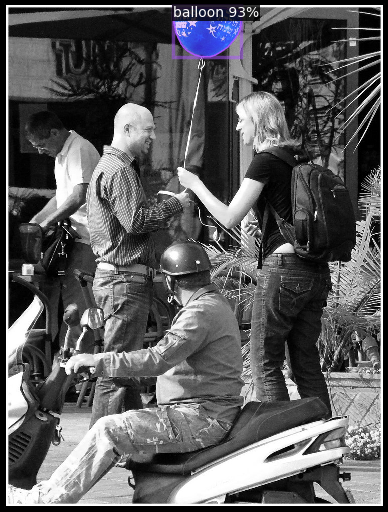

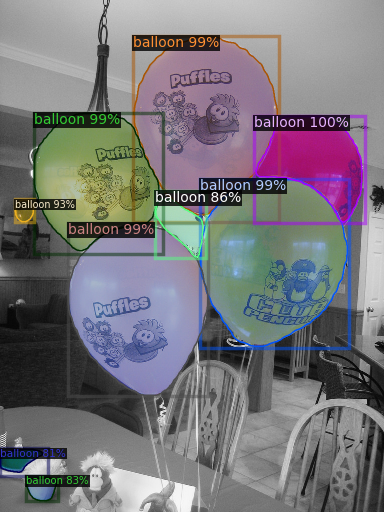

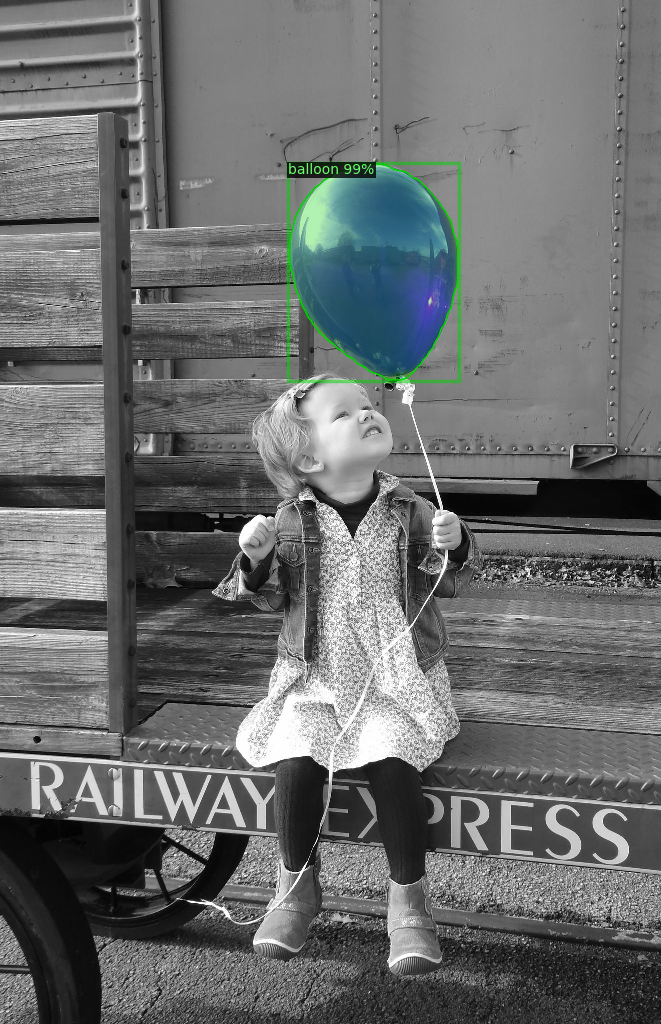

In [32]:
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_final.pth")  # path to the model we just trained
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.7   # set a custom testing threshold
predictor = DefaultPredictor(cfg)

dataset_dicts = get_balloon_dicts("balloon/val")

for d in random.sample(dataset_dicts, 3):
    im = cv2.imread(d["file_name"])
    outputs = predictor(im)  
    v = Visualizer(im[:, :, ::-1],
                   metadata=balloon_metadata,
                   scale=0.5,
                   instance_mode=ColorMode.IMAGE_BW   
    )
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
    img_pil = PIL.Image.fromarray(out.get_image())
    display(img_pil)